In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Generator , Literal
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.messages import SystemMessage,  ToolMessage
from pydantic import BaseModel, Field
from typing import List,operator
from langgraph.types import Send
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langchain.agents import create_agent
from langgraph.constants import Send

/Users/fakhrulislamfahad/Documents/Personal/agentic-ai/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/4y/hrml6n2j2nsdvdx747c5gmhr0000gn/T/ipykernel_19632/1822943232.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun
/var/folders/4y/hrml6n2j2nsdvdx747c5gmhr0000gn/T/ipykernel_19632/1822943232.py:22: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [3]:
llm = ChatOllama(model="qwen2.5:7b", temperature=0)


In [4]:
@tool
def calculator(first_num: float, second_num: float, operation: str) -> str:
    """Perform basic arithmetic. Operations: add, sub, mul, div"""
    if operation == "add": return str(first_num + second_num)
    if operation == "sub": return str(first_num - second_num)
    if operation == "mul": return str(first_num * second_num)
    if operation == "div":
        if second_num == 0: return "Error: division by zero"
        return str(first_num / second_num)
    return "Unknown operation"

@tool
def get_weather(city: str) -> str:
    """Get current weather for a city"""
    weather_data = {
        "dhaka":  "32°C, Humid",
        "london": "15°C, Cloudy",
        "dubai":  "41°C, Sunny",
    }
    return weather_data.get(city.lower(), f"Weather not found for {city}")

In [7]:
# LangGraph state: the data that flows through the workflow
class AgentState(TypedDict):
    question: str
    agents: List[str]
    reasoning: str
    answer: Annotated[List[str], operator.add]

class SuperVisorDecision(BaseModel):
    agents : List[str]
    reasoning : str

In [8]:
structure_llm = llm.with_structured_output(SuperVisorDecision)

In [9]:
def supervisor(state: AgentState):
    prompt = f"""
        Decide which specialist agents should answer.

        Available agents:

        math_agent
        weather_agent
        general_agent

        Question:
        {state["question"]}
    """
    decision = structure_llm.invoke(prompt)
    return {
        "agents": decision.agents,
        "reasoning": decision.reasoning
    }

In [10]:
math_llm = llm.bind_tools([calculator])
weather_llm = llm.bind_tools([get_weather])
def math_node(state: AgentState):
    messages = [HumanMessage(content=state["question"])]
    response = math_llm.invoke(messages)

    if response.tool_calls:
        messages.append(response)
        for tool_call in response.tool_calls:
            result = calculator.invoke(tool_call["args"])
            print(f"  [math_agent] calculator({tool_call['args']}) → {result}")
            messages.append(ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            ))
        final = math_llm.invoke(messages)
        return {"answer": [final.content]}

    return {"answer": [response.content]}


def weather_node(state: AgentState):
    messages = [HumanMessage(content=state["question"])]
    response = weather_llm.invoke(messages)

    if response.tool_calls:
        messages.append(response)
        for tool_call in response.tool_calls:
            result = get_weather.invoke(tool_call["args"])
            print(f"  [weather_agent] get_weather({tool_call['args']}) → {result}")
            messages.append(ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            ))
        final = weather_llm.invoke(messages)
        return {"answer": [final.content]}

    return {"answer": [response.content]}


def general_node(state: AgentState):
    response = llm.invoke(state["question"])
    return {"answer": [response.content]}


In [11]:
# parallel routing
def route_to_agents(state: AgentState):
    return [Send(agent, state) for agent in state["agents"]]

def combine(state: AgentState):
    final = "\n".join(state["answer"])
    return {"answer": [final]}


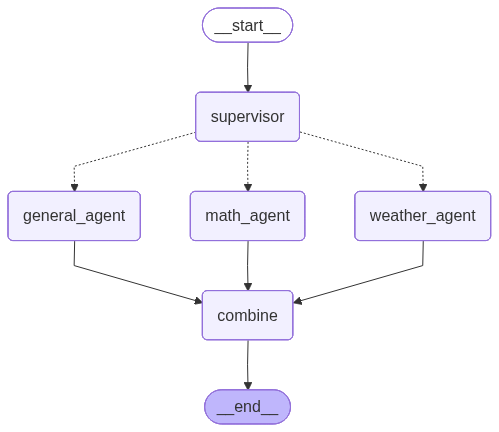

In [12]:
builder = StateGraph(AgentState)

builder.add_node("supervisor",    supervisor)
builder.add_node("math_agent",    math_node)
builder.add_node("weather_agent", weather_node)
builder.add_node("general_agent", general_node)
builder.add_node("combine",       combine)

builder.add_edge(START, "supervisor")

# ✅ Tell LangGraph which nodes this can route to
builder.add_conditional_edges(
    "supervisor",
    route_to_agents,
    ["math_agent", "weather_agent", "general_agent"]
)

builder.add_edge("math_agent",    "combine")
builder.add_edge("weather_agent", "combine")
builder.add_edge("general_agent", "combine")
builder.add_edge("combine", END)

graph = builder.compile()
graph

In [13]:
questions = [
    "What is 144 divided by 12?",
    "What is the weather in London?",
    "Who invented the telephone?",
    "What is the weather in Dhaka and what is 32 multiplied by 2?",
]

for q in questions:
    print(f"\n{'='*50}")
    print(f"Q: {q}")
    res = graph.invoke({"question": q, "agents": [], "answer": []})
    print(f"Final Answer:\n{res['answer'][-1]}")


Q: What is 144 divided by 12?
  [math_agent] calculator({'first_num': 144, 'operation': 'div', 'second_num': 12}) → 12.0
Final Answer:
The result of 144 divided by 12 is 12.0.

Q: What is the weather in London?
  [weather_agent] get_weather({'city': 'London'}) → 15°C, Cloudy
Final Answer:
The current weather in London is 15°C and it's cloudy.

Q: Who invented the telephone?
Final Answer:
The invention of the telephone is often attributed to Alexander Graham Bell, who was granted a patent for his telephone on March 7, 1876. However, it's important to note that there were other inventors working on similar technologies around the same time.

Elisha Gray filed a caveat (a preliminary notice of invention) for a device very similar to Bell's telephone on February 14, 1876, just hours before Bell submitted his patent application. Gray did not actually build or test his device, but he was close enough in his design that the two inventions are often considered contemporaneous.

Another notabl